In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from pandas.plotting import parallel_coordinates, scatter_matrix
from IPython.display import display

In [2]:
# Ustawienia czytelności
# =========================
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")

# =========================
# Funkcje pomocnicze
# =========================
def print_section(title):
    line = "=" * 90
    print(f"\n{line}\n{title}\n{line}")

def pop_var(a):
    a = np.asarray(a, dtype=float)
    m = np.mean(a)
    return np.mean((a - m) ** 2)

def pop_std(a):
    return np.sqrt(pop_var(a))

def mean_abs_dev(a):
    a = np.asarray(a, dtype=float)
    m = np.mean(a)
    return np.mean(np.abs(a - m))

def skew_coef(a):
    # As = (1/s^3) * (1/n) * sum((xi - xbar)^3)
    a = np.asarray(a, dtype=float)
    m = np.mean(a)
    s = pop_std(a)
    if s == 0:
        return np.nan
    return np.mean((a - m) ** 3) / (s ** 3)

def kurtosis_pearson(a):
    # Kurtoza Pearsona = m4 / (m2^2)
    a = np.asarray(a, dtype=float)
    m = np.mean(a)
    m2 = np.mean((a - m) ** 2)
    if m2 == 0:
        return np.nan
    m4 = np.mean((a - m) ** 4)
    return m4 / (m2 ** 2)

def safe_gmean(a):
    a = np.asarray(a, dtype=float)
    return np.nan if np.any(a <= 0) else stats.gmean(a)

def safe_hmean(a):
    a = np.asarray(a, dtype=float)
    return np.nan if np.any(a == 0) else stats.hmean(a)

def asymmetry_label(as_val, eps=0.05):
    if pd.isna(as_val):
        return "brak"
    if as_val > eps:
        return "prawostronna"
    if as_val < -eps:
        return "lewostronna"
    return "w przybliżeniu symetryczna"

def kurtosis_label(k_val, eps=0.05):
    if pd.isna(k_val):
        return "brak"
    if k_val > 3 + eps:
        return "leptokurtyczny"
    if k_val < 3 - eps:
        return "platykurtyczny"
    return "mezokurtyczny"


In [3]:
# Zadanie 1
# =========================
print_section("ZADANIE 1")

nr_gr = 5.5
r_k = 2026
seed = int(nr_gr * r_k)

np.random.seed(seed)
data_raw = pd.read_csv("carbig.csv")

columns = ["Acceleration", "Displacement", "Horsepower", "Weight", "MPG"]

print("Seed:")
print(f"seed = int({nr_gr} * {r_k}) = {seed}")

print("\nBraki danych przed uzupełnieniem:")
display(data_raw[columns + ["Cylinders"]].isna().sum().to_frame("liczba_brakow"))

data = data_raw.copy()

# Uzupełnienie braków modą w wymaganych kolumnach
for col in columns:
    data[col] = data[col].fillna(data[col].mode().iloc[0])

if "Cylinders" not in data.columns:
    raise ValueError("Brak kolumny 'Cylinders' w pliku carbig.csv.")

data["Cylinders"] = data["Cylinders"].fillna(data["Cylinders"].mode().iloc[0])

# Typy danych
data[columns] = data[columns].astype(float)
data["Cylinders"] = data["Cylinders"].astype(int)

# Zachowujemy kopię po imputacji, ale przed szumem
data_clean = data.copy()

# Macierz x i dodanie szumu ±1%
x = data_clean[columns].to_numpy(dtype=float)
noise_multiplier = 1 + (np.random.rand(*x.shape) * 2 - 1) / 100
x = x * noise_multiplier

# Dane robocze do dalszych zadań
data = data_clean.copy()
data.loc[:, columns] = x

print("\nBraki danych po uzupełnieniu:")
display(data[columns + ["Cylinders"]].isna().sum().to_frame("liczba_brakow"))

print("\nPodgląd danych (po dodaniu szumu):")
display(data[columns + ["Cylinders"]].head())

print("\nInformacje o zmiennych:")
display(data[columns + ["Cylinders"]].dtypes.to_frame("typ"))

print("\nOpis zmiennych numerycznych (po dodaniu szumu):")
display(data[columns].describe().round(4))

print("\nObjaśnienie wykonanych poleceń:")
print("- Wczytano plik carbig.csv.")
print("- Ustawiono ziarno generatora liczb losowych, aby wyniki były powtarzalne.")
print("- Braki danych w wymaganych kolumnach uzupełniono modą.")
print("- Wybrano kolumny numeryczne do macierzy x.")
print("- Dodano niewielki losowy szum ±1% do zmiennych numerycznych.")
print("- Kolumnę Cylinders zachowano do zadań 8 i 12.")



ZADANIE 1
Seed:
seed = int(5.5 * 2026) = 11143

Braki danych przed uzupełnieniem:


,liczba_brakow
Acceleration,0
Displacement,0
Horsepower,6
Weight,0
MPG,8
Cylinders,0



Braki danych po uzupełnieniu:


,liczba_brakow
Acceleration,0
Displacement,0
Horsepower,0
Weight,0
MPG,0
Cylinders,0



Podgląd danych (po dodaniu szumu):


...


Informacje o zmiennych:


,typ
Acceleration,float64
Displacement,float64
Horsepower,float64
Weight,float64
MPG,float64
Cylinders,int64



Opis zmiennych numerycznych (po dodaniu szumu):


,Acceleration,Displacement,Horsepower,Weight,MPG
count,406.0000,406.0000,406.0000,406.0000,406.0000
mean,15.5156,194.8133,105.7706,"2,979.0201",23.3134
std,2.7980,104.8982,38.8512,846.8803,7.8869
min,8.0436,67.8288,45.9786,"1,607.5390",9.0578
25%,13.6874,104.4730,75.6284,"2,235.8640",16.9111
50%,15.4117,149.6828,94.6940,"2,826.5178",22.3584
75%,17.1532,300.3755,131.2570,"3,602.3647",29.0671
max,24.7537,455.8613,230.4536,"5,142.7789",46.3528



Objaśnienie wykonanych poleceń:
- Wczytano plik carbig.csv.
- Ustawiono ziarno generatora liczb losowych, aby wyniki były powtarzalne.
- Braki danych w wymaganych kolumnach uzupełniono modą.
- Wybrano kolumny numeryczne do macierzy x.
- Dodano niewielki losowy szum ±1% do zmiennych numerycznych.
- Kolumnę Cylinders zachowano do zadań 8 i 12.


In [4]:
# Zadanie 2
# =========================
print_section("ZADANIE 2")

rows = []
for col in columns:
    a = data[col].to_numpy(dtype=float)                 # dane po szumie
    a_base = data_clean[col].to_numpy(dtype=float)      # dane po imputacji, przed szumem
    w = np.ones_like(a) / len(a)

    rows.append({
        "min": np.min(a),
        "max": np.max(a),
        "srednia_aryt": np.mean(a),
        "srednia_wazona_(rowne_wagi)": np.sum(w * a),
        "mediana": np.median(a),
        "moda_przed_szumem": pd.Series(a_base).mode().iloc[0],
        "srednia_geom": safe_gmean(a),
        "srednia_harm": safe_hmean(a),
    })

tab2 = pd.DataFrame(rows, index=columns).round(4)
display(tab2)

print("\nUwaga:")
print("Modę podano dla danych po imputacji, ale przed dodaniem szumu,")
print("ponieważ po dodaniu losowego szumu do danych ciągłych moda traci sens interpretacyjny.")


ZADANIE 2


,min,max,srednia_aryt,srednia_wazona_(rowne_wagi),mediana,moda_przed_szumem,srednia_geom,srednia_harm
Acceleration,8.0436,24.7537,15.5156,15.5156,15.4117,14.5000,15.2590,14.9933
Displacement,67.8288,455.8613,194.8133,194.8133,149.6828,97.0000,168.9717,148.0003
Horsepower,45.9786,230.4536,105.7706,105.7706,94.6940,150.0000,99.4279,93.8309
Weight,"1,607.5390","5,142.7789","2,979.0201","2,979.0201","2,826.5178","1,985.0000","2,863.6019","2,755.3129"
MPG,9.0578,46.3528,23.3134,23.3134,22.3584,13.0000,21.9976,20.7257



Uwaga:
Modę podano dla danych po imputacji, ale przed dodaniem szumu,
ponieważ po dodaniu losowego szumu do danych ciągłych moda traci sens interpretacyjny.



ZADANIE 3


,rozstep,Q1,Q2_mediana,Q3,IQR,odchylenie_cwiartkowe_Q,typowy_obszar_me_minus_Q,typowy_obszar_me_plus_Q
Acceleration,16.7101,13.6874,15.4117,17.1532,3.4658,1.7329,13.6788,17.1447
Displacement,388.0325,104.4730,149.6828,300.3755,195.9025,97.9513,51.7315,247.6341
Horsepower,184.4750,75.6284,94.6940,131.2570,55.6287,27.8143,66.8797,122.5084
Weight,"3,535.2399","2,235.8640","2,826.5178","3,602.3647","1,366.5007",683.2504,"2,143.2674","3,509.7682"
MPG,37.2950,16.9111,22.3584,29.0671,12.1560,6.0780,16.2804,28.4364


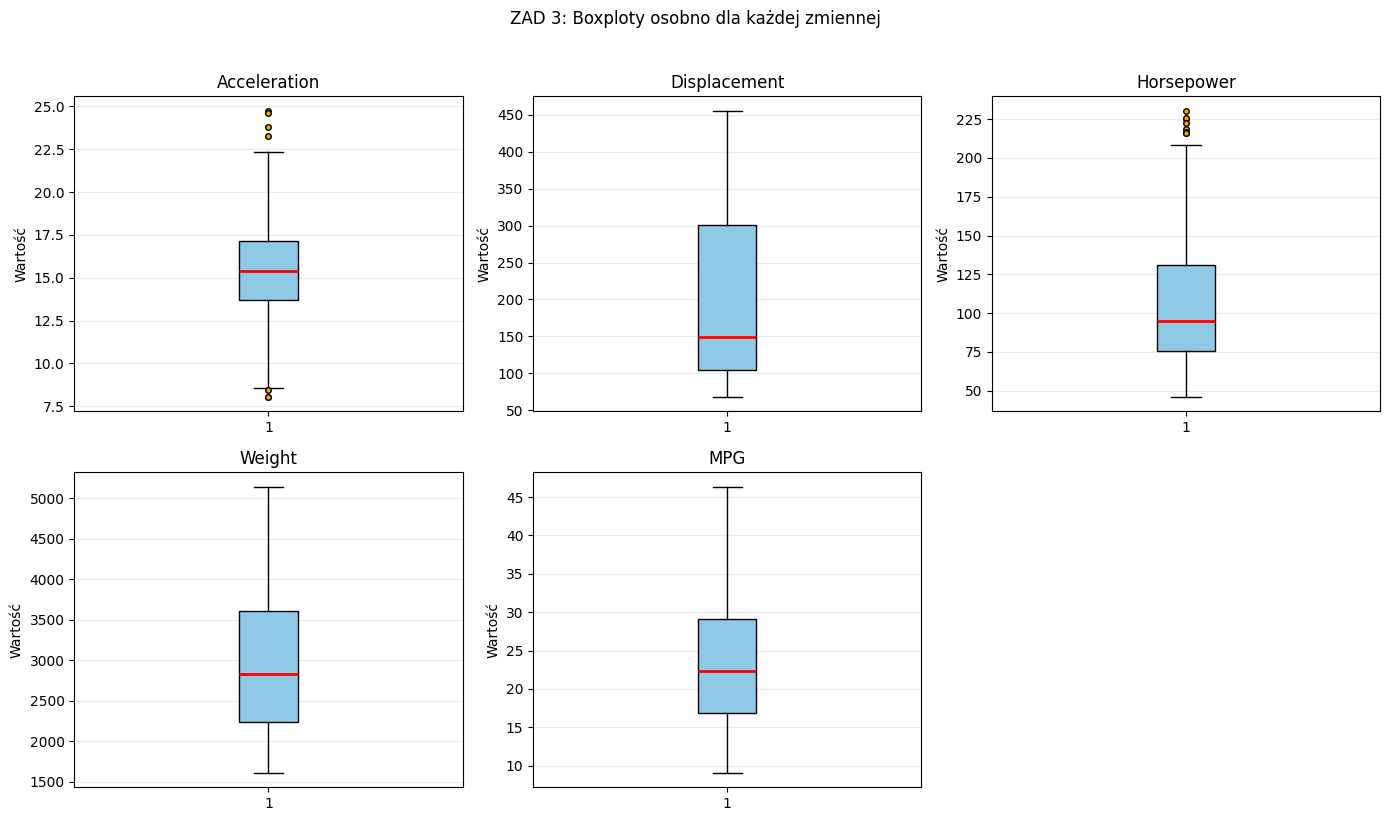

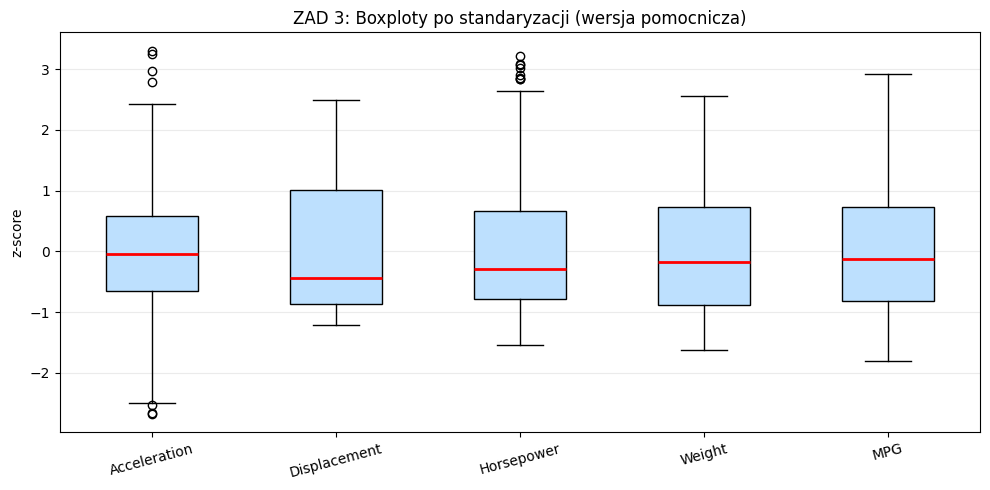


Uwaga:
Ze względu na bardzo różne skale zmiennych, zwłaszcza dużą skalę zmiennej `Weight`, wspólny boxplot był mało czytelny.
Dlatego przedstawiono osobne wykresy pudełkowe dla każdej zmiennej, co pozwala poprawnie ocenić medianę, rozstęp międzykwartylowy i obserwacje odstające.


In [5]:
# =========================
# Zadanie 3
# =========================
print_section("ZADANIE 3")

rows = []
for col in columns:
    a = data[col].to_numpy(dtype=float)
    q1, me, q3 = np.quantile(a, [0.25, 0.50, 0.75])
    iqr = q3 - q1
    Q = iqr / 2

    rows.append({
        "rozstep": np.max(a) - np.min(a),
        "Q1": q1,
        "Q2_mediana": me,
        "Q3": q3,
        "IQR": iqr,
        "odchylenie_cwiartkowe_Q": Q,
        "typowy_obszar_me_minus_Q": me - Q,
        "typowy_obszar_me_plus_Q": me + Q,
    })

tab3 = pd.DataFrame(rows, index=columns).round(4)
display(tab3)

# --- Wersja czytelna: osobny boxplot dla każdej zmiennej ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(columns):
    axes[i].boxplot(
        data[col].to_numpy(dtype=float),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#8ecae6", edgecolor="black"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, markeredgecolor='black')
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("Wartość")
    axes[i].grid(axis="y", alpha=0.25)

axes[-1].axis("off")
plt.suptitle("ZAD 3: Boxploty osobno dla każdej zmiennej", y=1.02)
plt.tight_layout()
plt.show()

# --- Opcjonalnie: wspólny boxplot po standaryzacji, tylko pomocniczo ---
data_z = pd.DataFrame(
    stats.zscore(data[columns].to_numpy(dtype=float), axis=0, ddof=0),
    columns=columns
)

plt.figure(figsize=(10, 5))
plt.boxplot(
    [data_z[c].to_numpy(dtype=float) for c in columns],
    tick_labels=columns,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor="#bde0fe", edgecolor="black"),
    medianprops=dict(color="red", linewidth=2)
)
plt.title("ZAD 3: Boxploty po standaryzacji (wersja pomocnicza)")
plt.ylabel("z-score")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("\nUwaga:")
print("Ze względu na bardzo różne skale zmiennych, zwłaszcza dużą skalę zmiennej `Weight`, wspólny boxplot był mało czytelny.")
print("Dlatego przedstawiono osobne wykresy pudełkowe dla każdej zmiennej, co pozwala poprawnie ocenić medianę, rozstęp międzykwartylowy i obserwacje odstające.")

In [6]:
# Zadanie 4
# =========================
print_section("ZADANIE 4")

rows = []
for col in columns:
    a = data[col].to_numpy(dtype=float)
    xbar = np.mean(a)
    d = mean_abs_dev(a)
    s2 = pop_var(a)
    s = pop_std(a)

    q1, me, q3 = np.quantile(a, [0.25, 0.50, 0.75])
    Q = (q3 - q1) / 2

    rows.append({
        "odch_przecietne_d": d,
        "wariancja_s2": s2,
        "odch_std_s": s,
        "typowy_obszar_xbar_minus_s": xbar - s,
        "typowy_obszar_xbar_plus_s": xbar + s,
        "wsp_zmien_pos_Q_me": (Q / me) if me != 0 else np.nan,
        "wsp_zmien_d_xbar": (d / xbar) if xbar != 0 else np.nan,
        "wsp_zmien_s_xbar": (s / xbar) if xbar != 0 else np.nan,
    })

tab4 = pd.DataFrame(rows, index=columns).round(4)
display(tab4)

print("\nUwaga:")
print("Wariancję i odchylenie standardowe policzono według wzorów ze slajdów, czyli z dzieleniem przez n.")



ZADANIE 4


,odch_przecietne_d,wariancja_s2,odch_std_s,typowy_obszar_xbar_minus_s,typowy_obszar_xbar_plus_s,wsp_zmien_pos_Q_me,wsp_zmien_d_xbar,wsp_zmien_s_xbar
Acceleration,2.1763,7.8094,2.7945,12.7211,18.3102,0.1124,0.1403,0.1801
Displacement,92.2042,"10,976.5401",104.7690,90.0443,299.5822,0.6544,0.4733,0.5378
Horsepower,31.1669,"1,505.6983",38.8033,66.9672,144.5739,0.2937,0.2947,0.3669
Weight,719.5571,"715,439.7510",845.8367,"2,133.1834","3,824.8568",0.2417,0.2415,0.2839
MPG,6.6060,62.0497,7.8772,15.4362,31.1905,0.2718,0.2834,0.3379



Uwaga:
Wariancję i odchylenie standardowe policzono według wzorów ze slajdów, czyli z dzieleniem przez n.



ZADANIE 5


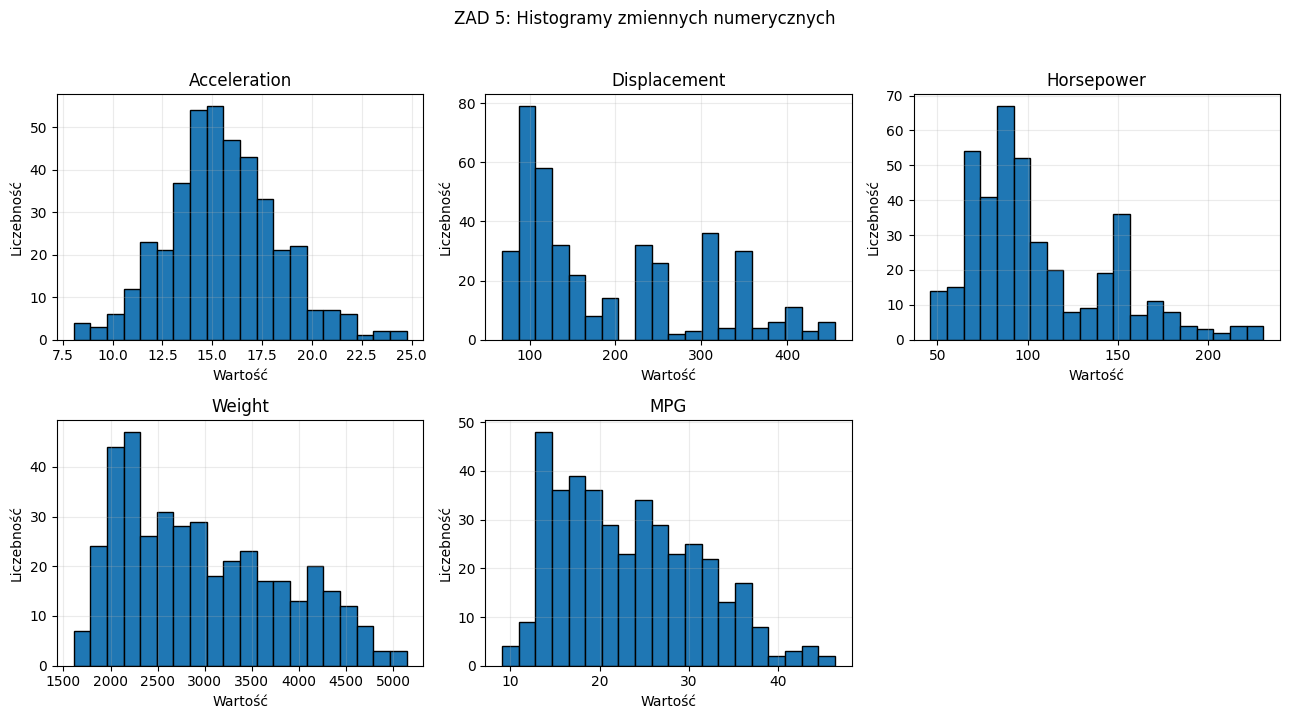

In [7]:
# Zadanie 5
# =========================
print_section("ZADANIE 5")

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for i, col in enumerate(columns):
    axes[i].hist(data[col].to_numpy(dtype=float), bins=20, edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("Wartość")
    axes[i].set_ylabel("Liczebność")
    axes[i].grid(alpha=0.25)

axes[-1].axis("off")
plt.suptitle("ZAD 5: Histogramy zmiennych numerycznych", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Zadanie 6
# =========================
print_section("ZADANIE 6")

rows = []
for col in columns:
    a = data[col].to_numpy(dtype=float)
    As = skew_coef(a)
    K = kurtosis_pearson(a)

    rows.append({
        "skew_As": As,
        "asymetria": asymmetry_label(As),
        "kurtoza_Pearsona": K,
        "typ_kurtozy": kurtosis_label(K)
    })

tab6 = pd.DataFrame(rows, index=columns).round(4)
display(tab6)



ZADANIE 6


,skew_As,asymetria,kurtoza_Pearsona,typ_kurtozy
Acceleration,0.2259,prawostronna,3.3619,leptokurtyczny
Displacement,0.6912,prawostronna,2.1825,platykurtyczny
Horsepower,0.9783,prawostronna,3.3896,leptokurtyczny
Weight,0.5041,prawostronna,2.1727,platykurtyczny
MPG,0.4695,prawostronna,2.4668,platykurtyczny



ZADANIE 7


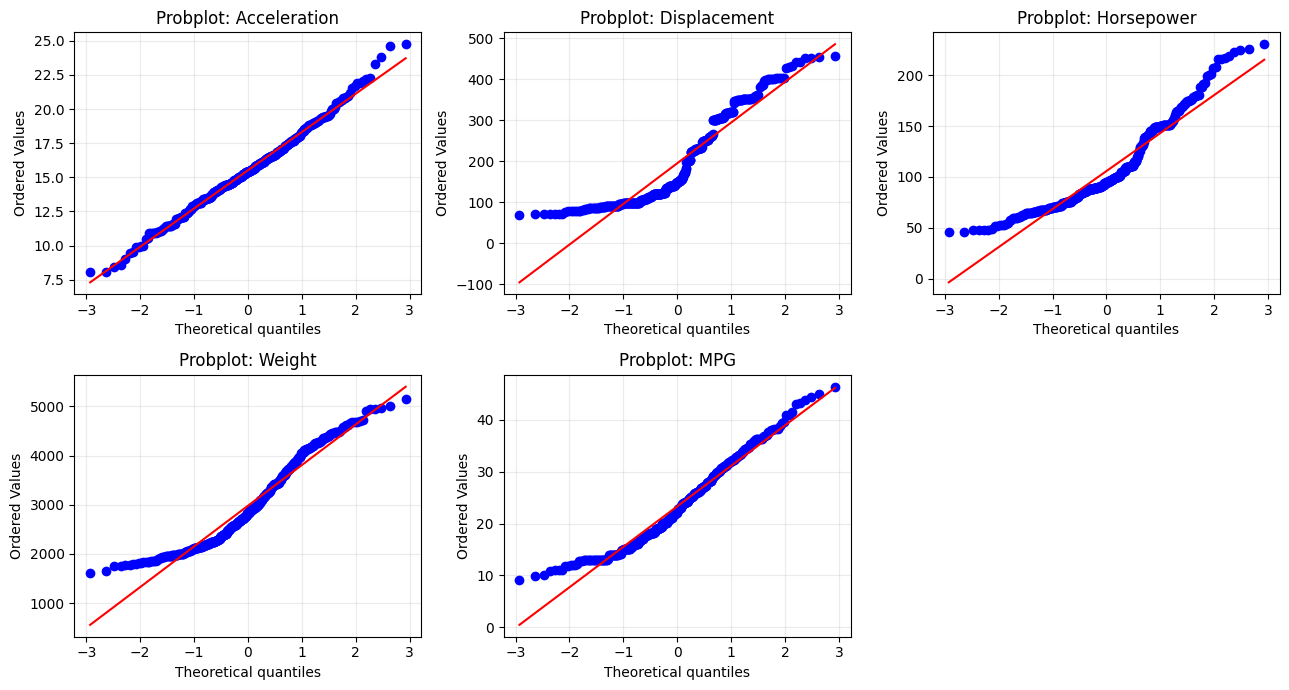

Wyjaśnienie:
Probplot porównuje kwantyle empiryczne badanej zmiennej z kwantylami teoretycznego rozkładu normalnego.
Jeżeli punkty leżą blisko prostej, to rozkład jest zbliżony do normalnego.
Odchylenia od prostej, zwłaszcza na końcach, mogą oznaczać asymetrię, cięższe ogony lub obserwacje odstające.


In [9]:
# Zadanie 7
# =========================
print_section("ZADANIE 7")

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for i, col in enumerate(columns):
    stats.probplot(data[col].to_numpy(dtype=float), dist="norm", plot=axes[i])
    axes[i].set_title(f"Probplot: {col}")
    axes[i].grid(alpha=0.25)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Wyjaśnienie:")
print("Probplot porównuje kwantyle empiryczne badanej zmiennej z kwantylami teoretycznego rozkładu normalnego.")
print("Jeżeli punkty leżą blisko prostej, to rozkład jest zbliżony do normalnego.")
print("Odchylenia od prostej, zwłaszcza na końcach, mogą oznaczać asymetrię, cięższe ogony lub obserwacje odstające.")



ZADANIE 8


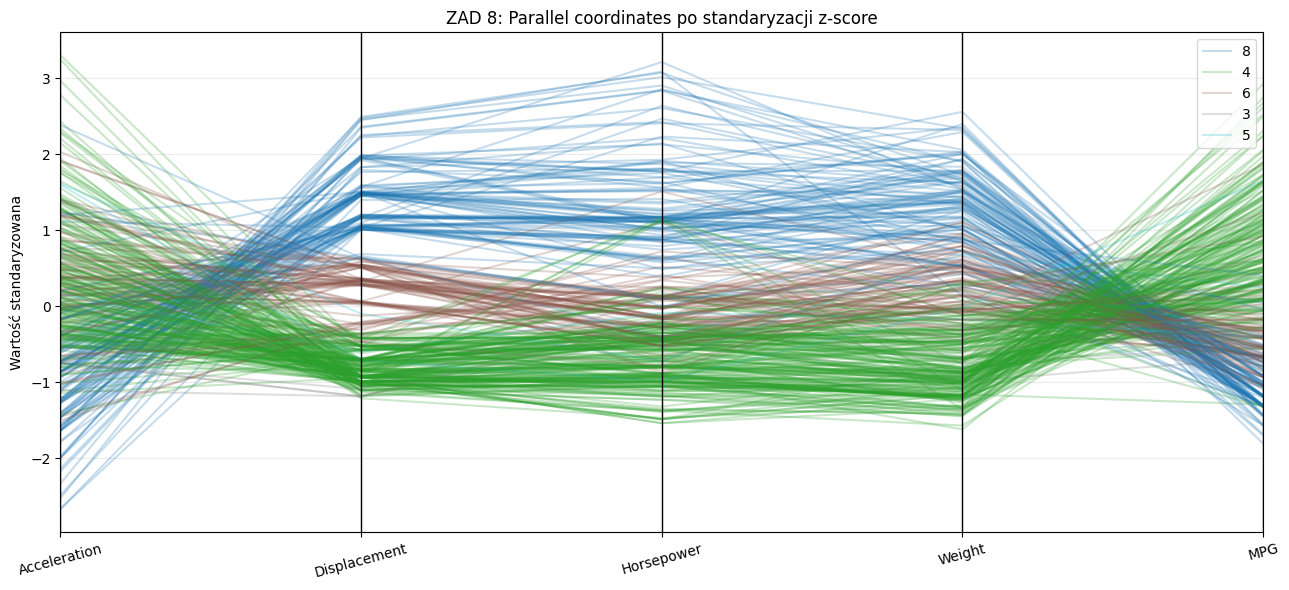

Średnie standaryzowane wartości cech w grupach cylindrów:


,Acceleration,Displacement,Horsepower,Weight,MPG
Cylinders,,,,,
3,-0.8370,-1.1640,-0.1610,-0.6730,-0.3570
4,0.3910,-0.8100,-0.6580,-0.7880,0.7300
5,1.1260,-0.4710,-0.5970,0.1680,0.4980
6,0.2640,0.2220,-0.0960,0.2570,-0.4220
8,-0.9560,1.4360,1.3580,1.3320,-1.0720


Interpretacja:
Po standaryzacji wszystkie zmienne są porównywalne mimo różnych jednostek.
Kolor linii odpowiada liczbie cylindrów.
Jeżeli linie danej klasy układają się podobnie, to auta z tą liczbą cylindrów mają zbliżony profil cech.
Duże rozdzielenie klas wskazuje na związek liczby cylindrów z parametrami pojazdu.


In [10]:
# Zadanie 8
# =========================
print_section("ZADANIE 8")

z = stats.zscore(data[columns].to_numpy(dtype=float), axis=0, ddof=0)
df_z = pd.DataFrame(z, columns=columns)
df_z["Cylinders"] = data["Cylinders"].astype(int).astype(str)

plt.figure(figsize=(13, 6))
parallel_coordinates(
    df_z,
    class_column="Cylinders",
    alpha=0.25,
    colormap=plt.cm.tab10
)
plt.title("ZAD 8: Parallel coordinates po standaryzacji z-score")
plt.ylabel("Wartość standaryzowana")
plt.xticks(rotation=15)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Średnie standaryzowane wartości cech w grupach cylindrów:")
display(df_z.groupby("Cylinders")[columns].mean().round(3))

print("Interpretacja:")
print("Po standaryzacji wszystkie zmienne są porównywalne mimo różnych jednostek.")
print("Kolor linii odpowiada liczbie cylindrów.")
print("Jeżeli linie danej klasy układają się podobnie, to auta z tą liczbą cylindrów mają zbliżony profil cech.")
print("Duże rozdzielenie klas wskazuje na związek liczby cylindrów z parametrami pojazdu.")



ZADANIE 9
Macierz korelacji Pearsona:


,Acceleration,Displacement,Horsepower,Weight,MPG
Acceleration,1.0000,-0.5571,-0.6745,-0.4294,0.4231
Displacement,-0.5571,1.0000,0.8746,0.9329,-0.7946
Horsepower,-0.6745,0.8746,1.0000,0.8441,-0.7474
Weight,-0.4294,0.9329,0.8441,1.0000,-0.8231
MPG,0.4231,-0.7946,-0.7474,-0.8231,1.0000


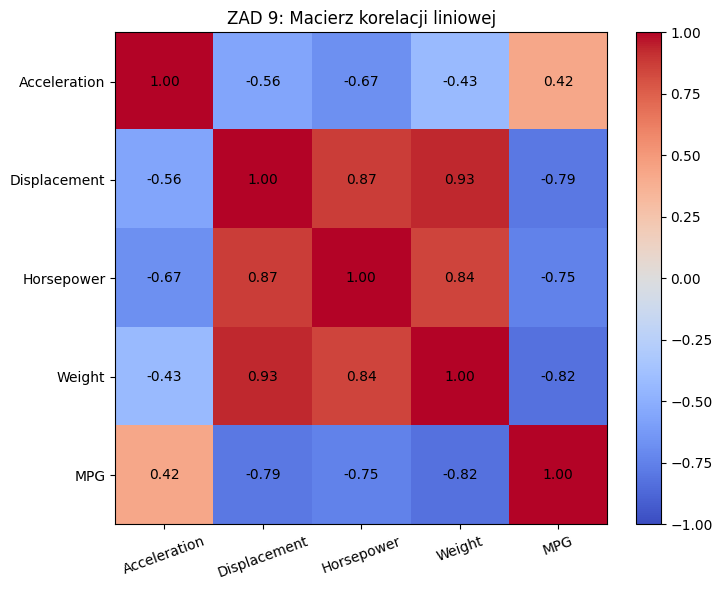

In [11]:
# Zadanie 9
# =========================
print_section("ZADANIE 9")

corr_matrix = data[columns].corr(method="pearson").round(4)
print("Macierz korelacji Pearsona:")
display(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(columns)))
ax.set_yticks(range(len(columns)))
ax.set_xticklabels(columns, rotation=20)
ax.set_yticklabels(columns)

for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.title("ZAD 9: Macierz korelacji liniowej")
plt.tight_layout()
plt.show()


ZADANIE 10


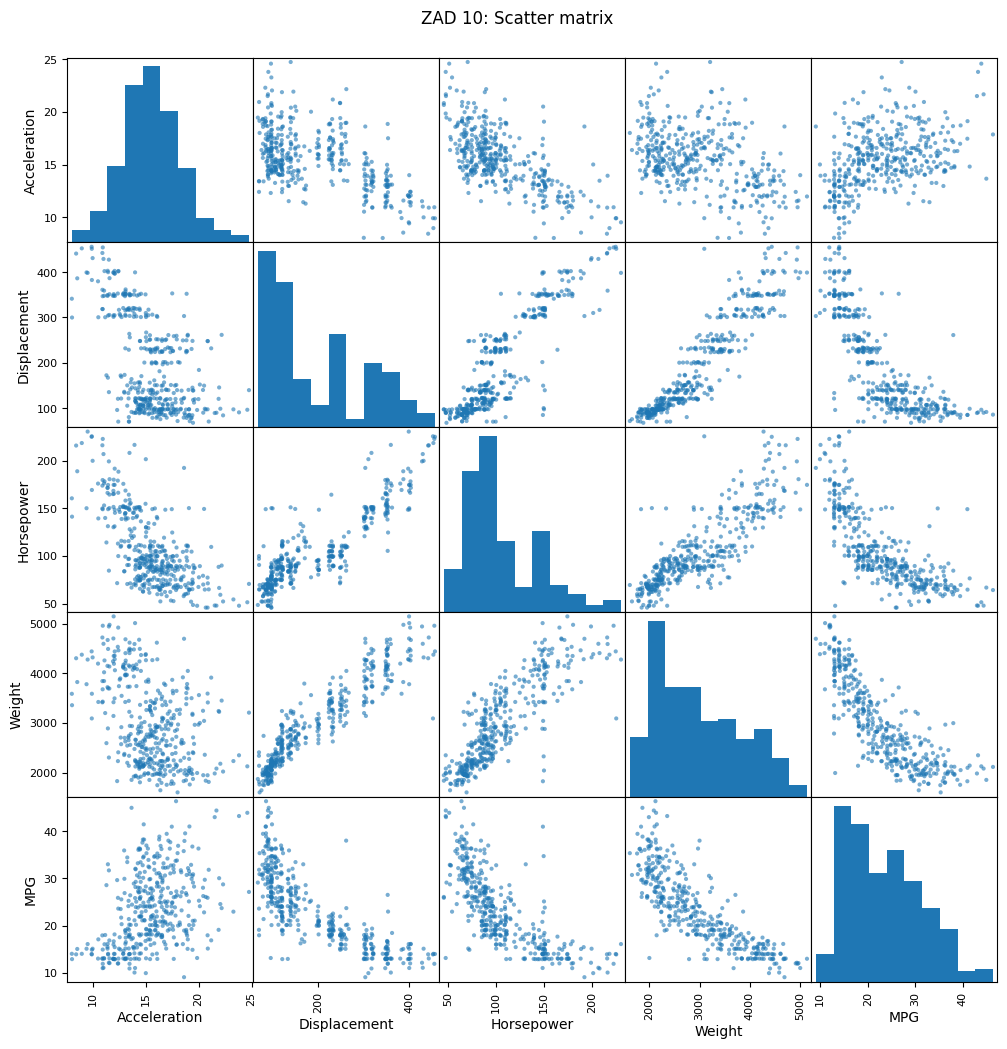

In [12]:
# Zadanie 10
# =========================
print_section("ZADANIE 10")

scatter_matrix(
    data[columns],
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.6,
    grid=True
)
plt.suptitle("ZAD 10: Scatter matrix", y=0.92)
plt.show()


ZADANIE 11
Podgląd kolumny Zuzycie:


,MPG,Zuzycie
0,18.1262,13.0681
1,15.1071,15.6797
2,17.9170,13.2207
3,15.9712,14.8314
4,17.0769,13.8711


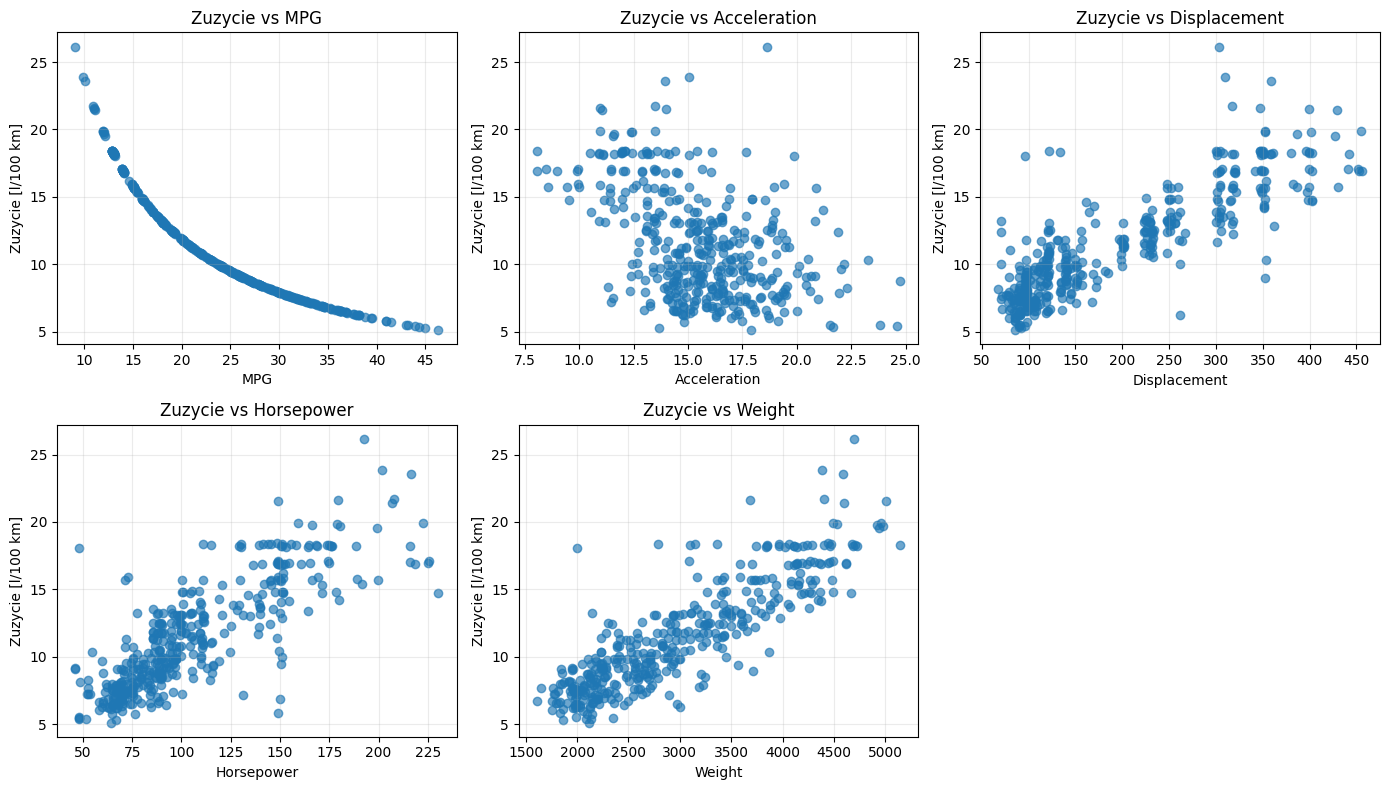

Interpretacja:
Zuzycie maleje wraz ze wzrostem MPG, ponieważ MPG i l/100 km są odwrotnie zależne.
Dla pozostałych zmiennych wykresy pokazują, czy większa masa, moc lub pojemność wiążą się z większym spalaniem.


In [13]:
# Zadanie 11
# =========================
print_section("ZADANIE 11")

# Zużycie paliwa w l/100 km
# 1 mila = 1.6 km, 1 galon = 3.79 litra
# l/100 km = (3.79 * 100) / (1.6 * MPG)
data["Zuzycie"] = (3.79 * 100) / (1.6 * data["MPG"])

print("Podgląd kolumny Zuzycie:")
display(data[["MPG", "Zuzycie"]].head().round(4))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

pairs = ["MPG", "Acceleration", "Displacement", "Horsepower", "Weight"]

for ax, col in zip(axes, pairs):
    ax.scatter(data[col], data["Zuzycie"], alpha=0.65)
    ax.set_xlabel(col)
    ax.set_ylabel("Zuzycie [l/100 km]")
    ax.set_title(f"Zuzycie vs {col}")
    ax.grid(alpha=0.25)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Interpretacja:")
print("Zuzycie maleje wraz ze wzrostem MPG, ponieważ MPG i l/100 km są odwrotnie zależne.")
print("Dla pozostałych zmiennych wykresy pokazują, czy większa masa, moc lub pojemność wiążą się z większym spalaniem.")


In [14]:
# Zadanie 12
# =========================
print_section("ZADANIE 12")

mean_consumption = (
    data[data["Cylinders"].isin([3, 4, 5, 6, 8])]
    .groupby("Cylinders")["Zuzycie"]
    .mean()
    .reindex([3, 4, 5, 6, 8])
    .to_frame("srednie_Zuzycie_l_na_100_km")
    .round(4)
)

display(mean_consumption)

print("Wniosek:")
print("Tabela pokazuje średnie zużycie paliwa dla samochodów z 3, 4, 5, 6 i 8 cylindrami.")


ZADANIE 12


,srednie_Zuzycie_l_na_100_km
Cylinders,
3,11.6821
4,8.5309
5,9.2228
6,12.1899
8,16.4440


Wniosek:
Tabela pokazuje średnie zużycie paliwa dla samochodów z 3, 4, 5, 6 i 8 cylindrami.


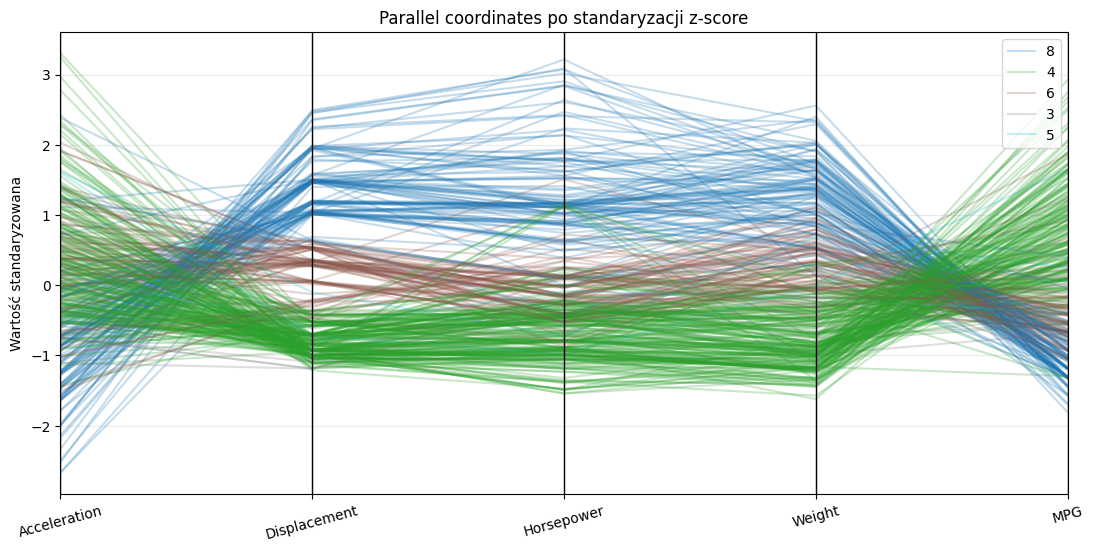

           Acceleration  Displacement  Horsepower  Weight     MPG
Cylinders                                                        
3               -0.8370       -1.1640     -0.1610 -0.6730 -0.3570
4                0.3910       -0.8100     -0.6580 -0.7880  0.7300
5                1.1260       -0.4710     -0.5970  0.1680  0.4980
6                0.2640        0.2220     -0.0960  0.2570 -0.4220
8               -0.9560        1.4360      1.3580  1.3320 -1.0720


In [15]:
z = stats.zscore(data[columns].to_numpy(dtype=float), axis=0, ddof=0)
df_z = pd.DataFrame(z, columns=columns)
df_z["Cylinders"] = data["Cylinders"].astype(int).astype(str)
plt.figure(figsize=(13, 6))
parallel_coordinates(df_z, class_column="Cylinders", alpha=0.25, colormap=plt.cm.tab10)
plt.title("Parallel coordinates po standaryzacji z-score")
plt.ylabel("Wartość standaryzowana")
plt.xticks(rotation=15)
plt.grid(alpha=0.25)
plt.show()
print(df_z.groupby("Cylinders")[columns].mean().round(3))

In [16]:
rows = []
for col in columns:
    a = data[col].to_numpy(dtype=float)
    As = skew_coef(a)
    K = kurtosis_pearson(a)

    rows.append({
      "skew_As": As,
      "asymetria": asymmetry_label(As),
      "kurtoza_Pearsona": K,
      "typ_kurtozy": kurtosis_label(K)
    })

tab6 = pd.DataFrame(rows, index=columns).round(4)
display(tab6)



,skew_As,asymetria,kurtoza_Pearsona,typ_kurtozy
Acceleration,0.2259,prawostronna,3.3619,leptokurtyczny
Displacement,0.6912,prawostronna,2.1825,platykurtyczny
Horsepower,0.9783,prawostronna,3.3896,leptokurtyczny
Weight,0.5041,prawostronna,2.1727,platykurtyczny
MPG,0.4695,prawostronna,2.4668,platykurtyczny


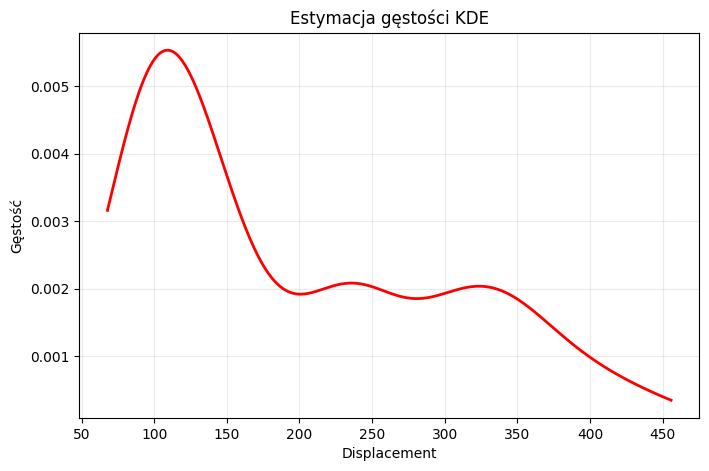

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

a = data["Displacement"].to_numpy(dtype=float)

x = np.linspace(a.min(), a.max(), 400)
kde = gaussian_kde(a)

plt.figure(figsize=(8, 5))
plt.plot(x, kde(x), color="red", linewidth=2)
plt.xlabel("Displacement")
plt.ylabel("Gęstość")
plt.title("Estymacja gęstości KDE")
plt.grid(alpha=0.25)
plt.show()
